# Fast LmrR EVB/QM workflow

This notebook lives directly in `D:\PhD_Thesis\LmrR_EVB\charges`.

It writes fast-job files to:

`D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_evb_qm`

It does **not** use the `results` folder.

In [1]:
#!/usr/bin/env python3
r"""
Fast LmrR EVB/QM preparation workflow.

This is meant to replace the slow "run everything in VeloxChem for all steps"
workflow.  By default it only prepares files; it does not launch expensive jobs.

Main ideas
----------
1. Preserve your PDB atom order and atom numbering by converting the existing
   capped PDB files to XYZ and writing a serial-to-XYZ-index map.
2. Prepare xTB jobs for fast pre-optimization of RS/TS/PS structures.
3. Optionally run xTB one step at a time if `xtb` is installed.
4. Export ORCA/Gaussian input files for final QM optimization/frequency jobs.
5. Optionally run the VeloxChem SMILES TS guesser in FAST mode only
   (no relaxed QM scan, no py3Dmol viewer).

Important
---------
- PDB serial numbers are not always the same as XYZ line indices, because the
  capped step-1 PDBs skip some serials. The generated `*_pdb_to_xyz_map.csv`
  files are therefore essential.
- The final barriers still require optimized RS/TS/PS energies and frequencies.
  This script gives fast starting points and final-QM input files.
"""

from __future__ import annotations

import argparse
import csv
import json
import math
import os
import shutil
import subprocess
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable


BASE_DIR = Path(r"D:\PhD_Thesis\LmrR_EVB")
CHARGES_DIR = BASE_DIR / "charges"
# Keep this workflow outside the `results` folder by default.
# The user wants code and generated fast-job files directly under `charges`.
RESULTS_DIR = CHARGES_DIR / "fast_lmrr_evb_qm"

HARTREE_TO_KJMOL = 2625.499638


@dataclass(frozen=True)
class PDBAtom:
    serial: int
    name: str
    resname: str
    chain: str
    resid: str
    x: float
    y: float
    z: float
    element: str

    @property
    def res_atom(self) -> str:
        return f"{self.resname}.{self.name}"

    @property
    def pdb_id(self) -> str:
        return f"{self.resid}.{self.name}"


@dataclass(frozen=True)
class BondChange:
    kind: str
    serial_i: int
    serial_j: int
    note: str


@dataclass(frozen=True)
class StructureSet:
    label: str
    rs_pdb: str
    ts_pdb: str
    ps_pdb: str
    charge: int
    multiplicity: int
    bond_changes: tuple[BondChange, ...]
    comment: str


STRUCTURE_SETS: dict[str, StructureSet] = {
    "RS1_1_to_TS1_2": StructureSet(
        label="RS1_1_to_TS1_2",
        rs_pdb="step_1_1_RS.pdb",
        ts_pdb="step_1_1_TS.pdb",
        ps_pdb="step_1_1_PS.pdb",
        charge=0,
        multiplicity=1,
        bond_changes=(
            BondChange("formed", 1, 10, "PAF.N2 attacks ENL.C10; N-C bond formation"),
            BondChange("weakened", 10, 16, "ENL.C10=O1 carbonyl weakens"),
        ),
        comment="Step 1.1 addition. Use TS as a starting TS guess; PS is the tetrahedral state.",
    ),
    "TS1_2_to_PS1_2b": StructureSet(
        label="TS1_2_to_PS1_2b",
        rs_pdb="step_1_2_RS.pdb",
        ts_pdb="step_1_2_TS.pdb",
        ps_pdb="step_1_2_PS.pdb",
        charge=0,
        multiplicity=1,
        bond_changes=(
            BondChange("broken", 1, 29, "PAF N-H breaks"),
            BondChange("formed", 27, 29, "W1 accepts H29"),
            BondChange("broken", 60, 61, "W2 O-H breaks"),
            BondChange("formed", 16, 61, "ENL.O1 accepts H61"),
        ),
        comment="Two-water proton redistribution.",
    ),
    "RS1_2b_to_PS1_3": StructureSet(
        label="RS1_2b_to_PS1_3",
        rs_pdb="step_1_3_RS.pdb",
        ts_pdb="step_1_3_TS.pdb",
        ps_pdb="step_1_3_PS.pdb",
        charge=0,
        multiplicity=1,
        bond_changes=(
            BondChange("broken", 27, 29, "W1 hydronium O-H breaks"),
            BondChange("formed", 16, 29, "carbinolamine O accepts H29"),
            BondChange("broken", 10, 16, "C-O leaving-water bond breaks"),
            BondChange("double-bond formed", 1, 10, "iminium N=C forms"),
        ),
        comment="Dehydration to iminium.",
    ),
    "RS2_1_to_TS2_1a": StructureSet(
        label="RS2_1_to_TS2_1a",
        rs_pdb="step_2_1_RS.pdb",
        ts_pdb="step_2_1_TS.pdb",
        ps_pdb="step_2_1_PS.pdb",
        charge=0,
        multiplicity=1,
        bond_changes=(
            BondChange("formed", 12, 20, "new C-C sigma bond ENL.C12--IND.C3"),
            BondChange("weakened", 1, 10, "iminium N=C weakens"),
            BondChange("strengthened", 10, 11, "C10-C11 bond strengthens"),
        ),
        comment="Friedel-Crafts C-C bond formation.",
    ),
    "TS2_1a_to_PS2_2": StructureSet(
        label="TS2_1a_to_PS2_2",
        # For the combined 2.2 tautomerization, use 2.2a RS as the early state,
        # 2.2b TS as the final-proton-transfer TS guess, and 2.2b PS as PS2.2.
        rs_pdb="step_2_2a_RS.pdb",
        ts_pdb="step_2_2b_TS.pdb",
        ps_pdb="step_2_2b_PS.pdb",
        charge=0,
        multiplicity=1,
        bond_changes=(
            BondChange("broken", 20, 50, "IND.C3-H50 breaks"),
            BondChange("formed", 60, 50, "W2 accepts H50"),
            BondChange("broken", 27, 58, "W1 O-H58 breaks"),
            BondChange("formed", 11, 58, "ENL.C11 accepts H58"),
            BondChange("double-bond formed", 1, 10, "N=C/enamine bond order changes"),
        ),
        comment="Combined 2.2 tautomerization. If you want separate 2.2a/2.2b, split this entry.",
    ),
}


STATE_SMILES = {
    "RS1.1": "CC(=O)NC(Cc1ccc(N)cc1)C(=O)NC.CCC/C=C/C=O",
    "TS1.2": "CC(=O)NC(Cc1ccc([NH2+][CH]([O-])/C=C/CCC)cc1)C(=O)NC",
    "PS1.2b": "CC(=O)NC(Cc1ccc(N[CH](O)/C=C/CCC)cc1)C(=O)NC",
    "RS1.2b": "CC(=O)NC(Cc1ccc(N[CH](O)/C=C/CCC)cc1)C(=O)NC",
    "PS1.3": "CC(=O)NC(Cc1ccc([NH+]=[CH]/C=C/CCC)cc1)C(=O)NC.O",
    "RS2.1": "CC(=O)NC(Cc1ccc([NH+]=[CH]/C=C/CCC)cc1)C(=O)NC.c1ccc2[nH]ccc2c1",
    "TS2.1a": "CC(=O)NC(Cc1ccc(N/C=C/C(CCC)C2C=[NH+]c3ccccc23)cc1)C(=O)NC",
    "PS2.2": "CC(=O)NC(Cc1ccc([NH+]=[CH]CC(CCC)c2c[nH]c3ccccc23)cc1)C(=O)NC",
    "H3O+": "[OH3+]",
    "H2O": "O",
}


SMILES_TRANSITIONS = {
    "RS1_1_to_TS1_2": (["RS1.1"], ["TS1.2"]),
    "TS1_2_to_PS1_2b": (["TS1.2"], ["PS1.2b"]),
    "RS1_2b_to_PS1_3": (["RS1.2b", "H3O+"], ["PS1.3", "H2O"]),
    "RS2_1_to_TS2_1a": (["RS2.1"], ["TS2.1a"]),
    "TS2_1a_to_PS2_2": (["TS2.1a"], ["PS2.2"]),
}


def selected_steps(step_args: Iterable[str] | None) -> list[str]:
    if not step_args:
        return list(STRUCTURE_SETS)
    out: list[str] = []
    for raw in step_args:
        for item in raw.split(","):
            item = item.strip()
            if not item:
                continue
            if item not in STRUCTURE_SETS:
                raise SystemExit(f"Unknown step {item!r}. Available: {', '.join(STRUCTURE_SETS)}")
            out.append(item)
    return out


def infer_element(atom_name: str, explicit: str = "") -> str:
    if explicit:
        return explicit.strip().capitalize()
    letters = "".join(ch for ch in atom_name if ch.isalpha())
    if not letters:
        return "X"
    two = letters[:2].capitalize()
    if two in {"Cl", "Br"}:
        return two
    return letters[0].upper()


def parse_pdb(path: Path) -> list[PDBAtom]:
    atoms: list[PDBAtom] = []
    for line in path.read_text(encoding="utf-8").splitlines():
        if not line.startswith(("ATOM  ", "HETATM")):
            continue
        atoms.append(
            PDBAtom(
                serial=int(line[6:11]),
                name=line[12:16].strip(),
                resname=line[17:20].strip(),
                chain=line[21:22].strip(),
                resid=line[22:26].strip(),
                x=float(line[30:38]),
                y=float(line[38:46]),
                z=float(line[46:54]),
                element=infer_element(line[12:16].strip(), line[76:78].strip()),
            )
        )
    if not atoms:
        raise ValueError(f"No atoms found in {path}")
    return atoms


def write_xyz_from_pdb(pdb_path: Path, xyz_path: Path, map_csv_path: Path) -> dict[int, int]:
    atoms = parse_pdb(pdb_path)
    xyz_path.parent.mkdir(parents=True, exist_ok=True)
    serial_to_xyz_index: dict[int, int] = {}
    with xyz_path.open("w", encoding="utf-8") as f:
        f.write(f"{len(atoms)}\n")
        f.write(f"from {pdb_path.name}; PDB serial map in {map_csv_path.name}\n")
        for xyz_index, atom in enumerate(atoms, start=1):
            serial_to_xyz_index[atom.serial] = xyz_index
            f.write(f"{atom.element:<2s} {atom.x:14.8f} {atom.y:14.8f} {atom.z:14.8f}\n")

    with map_csv_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "xyz_index",
                "pdb_serial",
                "pdb_id",
                "res_atom",
                "chain",
                "resid",
                "resname",
                "atom_name",
                "element",
            ],
        )
        writer.writeheader()
        for xyz_index, atom in enumerate(atoms, start=1):
            writer.writerow(
                {
                    "xyz_index": xyz_index,
                    "pdb_serial": atom.serial,
                    "pdb_id": atom.pdb_id,
                    "res_atom": atom.res_atom,
                    "chain": atom.chain,
                    "resid": atom.resid,
                    "resname": atom.resname,
                    "atom_name": atom.name,
                    "element": atom.element,
                }
            )
    return serial_to_xyz_index


def read_xyz(path: Path) -> tuple[list[str], list[tuple[float, float, float]], str]:
    lines = path.read_text(encoding="utf-8").splitlines()
    n = int(lines[0].strip())
    comment = lines[1] if len(lines) > 1 else ""
    labels: list[str] = []
    coords: list[tuple[float, float, float]] = []
    for line in lines[2 : 2 + n]:
        parts = line.split()
        labels.append(parts[0])
        coords.append((float(parts[1]), float(parts[2]), float(parts[3])))
    return labels, coords, comment


def distance_from_xyz(xyz_path: Path, idx_i: int, idx_j: int) -> float:
    _, coords, _ = read_xyz(xyz_path)
    xi, yi, zi = coords[idx_i - 1]
    xj, yj, zj = coords[idx_j - 1]
    return math.sqrt((xi - xj) ** 2 + (yi - yj) ** 2 + (zi - zj) ** 2)


def write_xtb_constraint(path: Path, constraints: list[tuple[int, int, float]]) -> None:
    lines = ["$constrain"]
    for i, j, dist in constraints:
        lines.append(f"  distance: {i}, {j}, {dist:.4f}")
    lines.append("$end")
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")


def write_xtb_runner(
    run_path: Path,
    xyz_path: Path,
    charge: int,
    multiplicity: int,
    constraint_file: Path | None,
    output_prefix: str,
) -> None:
    uhf = max(0, multiplicity - 1)
    cmd = [
        "xtb",
        xyz_path.name,
        "--gfn",
        "2",
        "--opt",
        "tight",
        "--chrg",
        str(charge),
        "--uhf",
        str(uhf),
    ]
    if constraint_file is not None:
        cmd.extend(["--input", constraint_file.name])
    command = " ".join(cmd)
    run_path.write_text(
        "\n".join(
            [
                "$ErrorActionPreference = 'Stop'",
                f"Set-Location -LiteralPath '{run_path.parent}'",
                command + f" *> {output_prefix}.xtb.log",
                "if (Test-Path xtbopt.xyz) {",
                f"    Copy-Item -LiteralPath xtbopt.xyz -Destination {output_prefix}_xtbopt.xyz -Force",
                "}",
                "if (Test-Path xtbopt.log) {",
                f"    Copy-Item -LiteralPath xtbopt.log -Destination {output_prefix}_xtbopt.log -Force",
                "}",
                "if (Test-Path xtbrestart) {",
                f"    Copy-Item -LiteralPath xtbrestart -Destination {output_prefix}.xtbrestart -Force",
                "}",
                "",
            ]
        ),
        encoding="utf-8",
    )


def write_orca_input(
    inp_path: Path,
    xyz_path: Path,
    charge: int,
    multiplicity: int,
    job_type: str,
    nprocs: int = 8,
    memory_mb: int = 3000,
) -> None:
    labels, coords, _ = read_xyz(xyz_path)
    if job_type == "ts":
        route = "! B3LYP D3BJ def2-SVP OptTS NumFreq TightSCF"
    elif job_type == "freq":
        route = "! B3LYP D3BJ def2-SVP Freq TightSCF"
    else:
        route = "! B3LYP D3BJ def2-SVP Opt Freq TightSCF"
    lines = [
        route,
        f"%pal nprocs {nprocs} end",
        f"%maxcore {memory_mb}",
        "",
        f"* xyz {charge} {multiplicity}",
    ]
    for label, (x, y, z) in zip(labels, coords):
        lines.append(f"  {label:<2s} {x:14.8f} {y:14.8f} {z:14.8f}")
    lines.append("*")
    lines.append("")
    inp_path.write_text("\n".join(lines), encoding="utf-8")


def write_gaussian_input(
    gjf_path: Path,
    xyz_path: Path,
    charge: int,
    multiplicity: int,
    job_type: str,
    nprocs: int = 8,
    memory_gb: int = 16,
) -> None:
    labels, coords, _ = read_xyz(xyz_path)
    opt_keyword = "Opt=(TS,CalcFC,NoEigenTest) Freq" if job_type == "ts" else "Opt Freq"
    lines = [
        f"%nprocshared={nprocs}",
        f"%mem={memory_gb}GB",
        f"#p B3LYP/def2SVP EmpiricalDispersion=GD3BJ {opt_keyword}",
        "",
        f"{xyz_path.stem} {job_type}",
        "",
        f"{charge} {multiplicity}",
    ]
    for label, (x, y, z) in zip(labels, coords):
        lines.append(f"{label:<2s} {x:14.8f} {y:14.8f} {z:14.8f}")
    lines.extend(["", ""])
    gjf_path.write_text("\n".join(lines), encoding="utf-8")


def prepare_pdb_preserving_jobs(steps: list[str], overwrite: bool = True) -> None:
    prep_dir = RESULTS_DIR / "pdb_preserving_xtb_qm_inputs"
    prep_dir.mkdir(parents=True, exist_ok=True)
    summary_rows = []

    for step in steps:
        cfg = STRUCTURE_SETS[step]
        step_dir = prep_dir / step
        step_dir.mkdir(parents=True, exist_ok=True)
        serial_maps: dict[str, dict[int, int]] = {}

        for role, pdb_name, qm_job_type in [
            ("RS", cfg.rs_pdb, "min"),
            ("TS", cfg.ts_pdb, "ts"),
            ("PS", cfg.ps_pdb, "min"),
        ]:
            pdb_path = CHARGES_DIR / pdb_name
            if not pdb_path.exists():
                raise FileNotFoundError(pdb_path)
            xyz_path = step_dir / f"{step}_{role}.xyz"
            map_csv = step_dir / f"{step}_{role}_pdb_to_xyz_map.csv"
            if overwrite or not xyz_path.exists():
                serial_maps[role] = write_xyz_from_pdb(pdb_path, xyz_path, map_csv)
            else:
                # Read existing map.
                serial_maps[role] = {}
                with map_csv.open(newline="", encoding="utf-8") as f:
                    for row in csv.DictReader(f):
                        serial_maps[role][int(row["pdb_serial"])] = int(row["xyz_index"])

            write_orca_input(step_dir / f"{step}_{role}.inp", xyz_path, cfg.charge, cfg.multiplicity, qm_job_type)
            write_gaussian_input(step_dir / f"{step}_{role}.gjf", xyz_path, cfg.charge, cfg.multiplicity, qm_job_type)
            write_xtb_runner(
                step_dir / f"run_xtb_{role}.ps1",
                xyz_path,
                cfg.charge,
                cfg.multiplicity,
                constraint_file=None,
                output_prefix=f"{step}_{role}",
            )

            summary_rows.append(
                {
                    "step": step,
                    "role": role,
                    "pdb": str(pdb_path),
                    "xyz": str(xyz_path),
                    "map_csv": str(map_csv),
                    "orca_input": str(step_dir / f"{step}_{role}.inp"),
                    "gaussian_input": str(step_dir / f"{step}_{role}.gjf"),
                    "xtb_runner": str(step_dir / f"run_xtb_{role}.ps1"),
                    "charge": cfg.charge,
                    "multiplicity": cfg.multiplicity,
                    "comment": cfg.comment,
                }
            )

        # Write constrained xTB TS preoptimization for the TS structure.
        ts_xyz = step_dir / f"{step}_TS.xyz"
        ts_map = serial_maps["TS"]
        constraints: list[tuple[int, int, float]] = []
        for change in cfg.bond_changes:
            if change.kind in {"formed", "broken", "double-bond formed"}:
                if change.serial_i in ts_map and change.serial_j in ts_map:
                    i_xyz = ts_map[change.serial_i]
                    j_xyz = ts_map[change.serial_j]
                    dist = distance_from_xyz(ts_xyz, i_xyz, j_xyz)
                    constraints.append((i_xyz, j_xyz, dist))
        if constraints:
            constraint_file = step_dir / f"{step}_TS_xtb_constraints.inp"
            write_xtb_constraint(constraint_file, constraints)
            write_xtb_runner(
                step_dir / "run_xtb_TS_constrained.ps1",
                ts_xyz,
                cfg.charge,
                cfg.multiplicity,
                constraint_file=constraint_file,
                output_prefix=f"{step}_TS_constrained",
            )

        # Human-readable bond map for this step.
        atoms = parse_pdb(CHARGES_DIR / cfg.ts_pdb)
        by_serial = {a.serial: a for a in atoms}
        bond_lines = [
            f"# {step}",
            f"# {cfg.comment}",
            "# PDB serial -> atom identity; XYZ index is taken from TS map",
        ]
        for change in cfg.bond_changes:
            ai = by_serial[change.serial_i]
            aj = by_serial[change.serial_j]
            bond_lines.append(
                f"{change.kind:18s} PDB {change.serial_i:>3}-{change.serial_j:<3} "
                f"XYZ {ts_map[change.serial_i]:>3}-{ts_map[change.serial_j]:<3} "
                f"{ai.res_atom} -- {aj.res_atom} ; {change.note}"
            )
        (step_dir / f"{step}_bond_map.txt").write_text("\n".join(bond_lines) + "\n", encoding="utf-8")

    summary_csv = prep_dir / "prepared_fast_jobs_summary.csv"
    with summary_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "step",
                "role",
                "pdb",
                "xyz",
                "map_csv",
                "orca_input",
                "gaussian_input",
                "xtb_runner",
                "charge",
                "multiplicity",
                "comment",
            ],
        )
        writer.writeheader()
        writer.writerows(summary_rows)
    print(f"Prepared PDB-preserving xTB/QM inputs in: {prep_dir}")
    print(f"Summary: {summary_csv}")


def run_xtb_jobs(steps: list[str], roles: list[str]) -> None:
    xtb = shutil.which("xtb")
    if not xtb:
        raise SystemExit(
            "Could not find xtb on PATH. Install xTB or use the prepared run_xtb_*.ps1 files on a machine with xTB."
        )
    prep_dir = RESULTS_DIR / "pdb_preserving_xtb_qm_inputs"
    for step in steps:
        step_dir = prep_dir / step
        for role in roles:
            runner = step_dir / f"run_xtb_{role}.ps1"
            if role == "TS_constrained":
                runner = step_dir / "run_xtb_TS_constrained.ps1"
            if not runner.exists():
                print(f"Skipping missing runner: {runner}")
                continue
            print(f"Running {runner}")
            subprocess.run(["powershell", "-NoProfile", "-ExecutionPolicy", "Bypass", "-File", str(runner)], check=True)


def _safe_float(value):
    try:
        return float(value)
    except Exception:
        return None


def _scan_items(result):
    scan = result.get("scan", {}) if isinstance(result, dict) else {}
    if not isinstance(scan, dict):
        return []
    items = []
    for lam, records in scan.items():
        if isinstance(records, dict):
            records = [records]
        for idx, rec in enumerate(records or []):
            if isinstance(rec, dict):
                items.append((lam, idx, rec))
    return items


def write_text(path: Path, text: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")


def write_csv(path: Path, rows: list[dict], fieldnames: list[str]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def run_veloxchem_fast(steps: list[str]) -> None:
    try:
        import veloxchem as vlx
    except Exception as exc:
        raise SystemExit(f"VeloxChem is not importable in this Python environment: {exc}") from exc

    out_dir = RESULTS_DIR / "veloxchem_fast_smiles_guesses"
    out_dir.mkdir(parents=True, exist_ok=True)
    summary_rows = []

    for step in steps:
        reactant_labels, product_labels = SMILES_TRANSITIONS[step]
        reactants = [vlx.Molecule.read_smiles(STATE_SMILES[label]) for label in reactant_labels]
        products = [vlx.Molecule.read_smiles(STATE_SMILES[label]) for label in product_labels]

        guesser = vlx.TransitionStateGuesser()
        # The key speed choices: no QM rescoring/relaxed QM scan and no viewer.
        for attr, value in [
            ("scf_scan", False),
            ("do_qm_scan", False),
            ("qm_scan", False),
            ("optimize_ts", False),
            ("do_ts_optimization", False),
            ("mute_ff_build", True),
        ]:
            if hasattr(guesser, attr):
                setattr(guesser, attr, value)

        print(f"\n=== VeloxChem FAST guess: {step} ===")
        result = guesser.find_transition_state(reactants, products)
        step_dir = out_dir / step
        step_dir.mkdir(parents=True, exist_ok=True)

        for key in ["max_mm_xyz", "max_qm_xyz"]:
            if isinstance(result, dict) and key in result:
                write_text(step_dir / f"{step}_{key}.xyz", result[key])

        scan_rows = []
        for lam, idx, rec in _scan_items(result):
            xyz = rec.get("qm_xyz") or rec.get("mm_xyz") or rec.get("xyz")
            if xyz:
                write_text(step_dir / f"lambda_{float(lam):.2f}_conf_{idx}.xyz", xyz)
            scan_rows.append(
                {
                    "step": step,
                    "lambda": float(lam),
                    "conformer_index": idx,
                    "mm_energy": rec.get("mm_energy", ""),
                    "qm_energy": rec.get("qm_energy", ""),
                    "has_xyz": bool(xyz),
                }
            )
        if scan_rows:
            write_csv(
                step_dir / f"{step}_veloxchem_fast_scan.csv",
                scan_rows,
                ["step", "lambda", "conformer_index", "mm_energy", "qm_energy", "has_xyz"],
            )

        summary_rows.append(
            {
                "step": step,
                "reactants": " + ".join(reactant_labels),
                "products": " + ".join(product_labels),
                "result_keys": ", ".join(result.keys()) if isinstance(result, dict) else "",
                "max_mm_lambda": result.get("max_mm_lambda", "") if isinstance(result, dict) else "",
                "max_qm_lambda": result.get("max_qm_lambda", "") if isinstance(result, dict) else "",
                "scan_points": len(scan_rows),
                "folder": str(step_dir),
            }
        )

    write_csv(
        out_dir / "veloxchem_fast_summary.csv",
        summary_rows,
        ["step", "reactants", "products", "result_keys", "max_mm_lambda", "max_qm_lambda", "scan_points", "folder"],
    )
    print(f"\nVeloxChem fast outputs: {out_dir}")


def write_readme() -> None:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    readme = RESULTS_DIR / "README_fast_workflow.md"
    readme.write_text(
        """# Fast LmrR EVB/QM workflow

This folder is generated by `fast_lmrr_evb_qm_workflow.py`.

Recommended fast route:

1. Prepare PDB-preserving XYZ, xTB runners, and final-QM input files:

   ```powershell
   python fast_lmrr_evb_qm_workflow.py --prepare
   ```

2. Run xTB only for one step/role at a time, for example:

   ```powershell
   python fast_lmrr_evb_qm_workflow.py --run-xtb --steps RS2_1_to_TS2_1a --roles RS,TS,PS
   ```

   Or run the generated `run_xtb_*.ps1` files manually inside each step folder.

3. Use the generated ORCA `.inp` or Gaussian `.gjf` files for final B3LYP-D/def2-SVP
   optimization/frequency calculations.

4. Use VeloxChem only for quick SMILES TS guesses:

   ```powershell
   python fast_lmrr_evb_qm_workflow.py --veloxchem-fast --steps RS2_1_to_TS2_1a
   ```

Do not run all relaxed QM scans for all five steps in one notebook. That is the slow
path that can consume days without useful intermediate stopping points.
""",
        encoding="utf-8",
    )


def main() -> None:
    parser = argparse.ArgumentParser(description="Fast LmrR EVB/QM preparation workflow.")
    parser.add_argument("--steps", nargs="*", help="Step labels, comma-separated or space-separated.")
    parser.add_argument("--prepare", action="store_true", help="Prepare PDB-preserving XYZ/xTB/QM input files.")
    parser.add_argument("--run-xtb", action="store_true", help="Run prepared xTB jobs. Requires xtb on PATH.")
    parser.add_argument(
        "--roles",
        default="RS,TS,PS",
        help="Roles for --run-xtb: RS,TS,PS,TS_constrained. Default: RS,TS,PS.",
    )
    parser.add_argument("--veloxchem-fast", action="store_true", help="Run fast VeloxChem SMILES TS guesses only.")
    parser.add_argument("--list-steps", action="store_true", help="Print available step labels and exit.")
    args = parser.parse_args()

    if args.list_steps:
        print("\n".join(STRUCTURE_SETS))
        return

    steps = selected_steps(args.steps)
    write_readme()

    if not args.prepare and not args.run_xtb and not args.veloxchem_fast:
        print("No action requested. Preparing files by default.")
        args.prepare = True

    if args.prepare:
        prepare_pdb_preserving_jobs(steps)
    if args.run_xtb:
        roles = [x.strip() for x in args.roles.split(",") if x.strip()]
        run_xtb_jobs(steps, roles)
    if args.veloxchem_fast:
        run_veloxchem_fast(steps)

## Check xTB path

Run this first. If it prints `None`, xTB is not installed or not on PATH.

In [2]:
import os, shutil
from pathlib import Path

# If xTB is installed but not on PATH, paste the full xtb.exe path here:
XTB_EXE = r""  # example: r"C:\Users\Nayanika\miniconda3\envs\xtb\Library\bin\xtb.exe"

if XTB_EXE and Path(XTB_EXE).exists():
    os.environ["PATH"] = str(Path(XTB_EXE).parent) + os.pathsep + os.environ["PATH"]

print("xtb found:", shutil.which("xtb"))
print("workflow output folder:", RESULTS_DIR)

xtb found: None
workflow output folder: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_evb_qm


## Available EVB steps and PDB files

In [3]:
for step, cfg in STRUCTURE_SETS.items():
    print(step)
    print("  RS:", cfg.rs_pdb)
    print("  TS:", cfg.ts_pdb)
    print("  PS:", cfg.ps_pdb)
    print()

RS1_1_to_TS1_2
  RS: step_1_1_RS.pdb
  TS: step_1_1_TS.pdb
  PS: step_1_1_PS.pdb

TS1_2_to_PS1_2b
  RS: step_1_2_RS.pdb
  TS: step_1_2_TS.pdb
  PS: step_1_2_PS.pdb

RS1_2b_to_PS1_3
  RS: step_1_3_RS.pdb
  TS: step_1_3_TS.pdb
  PS: step_1_3_PS.pdb

RS2_1_to_TS2_1a
  RS: step_2_1_RS.pdb
  TS: step_2_1_TS.pdb
  PS: step_2_1_PS.pdb

TS2_1a_to_PS2_2
  RS: step_2_2a_RS.pdb
  TS: step_2_2b_TS.pdb
  PS: step_2_2b_PS.pdb



## Prepare files only

Creates XYZ/maps/xTB runners/ORCA/Gaussian inputs under `charges
ast_lmrr_evb_qm`. Does not run xTB/QM.

In [4]:
import os, shutil
from pathlib import Path

XTB_EXE = r"C:\Users\Nayanika\miniconda3\envs\quimica-echem\Library\bin\xtb.exe"

os.environ["PATH"] = str(Path(XTB_EXE).parent) + os.pathsep + os.environ["PATH"]

print("xtb found:", shutil.which("xtb"))

prepare_pdb_preserving_jobs(list(STRUCTURE_SETS))

xtb found: C:\Users\Nayanika\miniconda3\envs\quimica-echem\Library\bin\xtb.EXE


Prepared PDB-preserving xTB/QM inputs in: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_evb_qm\pdb_preserving_xtb_qm_inputs
Summary: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_evb_qm\pdb_preserving_xtb_qm_inputs\prepared_fast_jobs_summary.csv


In [5]:
import shutil
import os
from pathlib import Path

# Where you extracted the official xTB
XTB_DIR = Path(r"C:\Users\Nayanika\Downloads\xtb-6.7.1pre-windows-x86_64")

# Search for xtb.exe recursively
xtb_exe = None
for exe in XTB_DIR.rglob("xtb.exe"):
    xtb_exe = exe
    break

if xtb_exe is None:
    # Also check if xtb is in PATH
    path_xtb = shutil.which("xtb")
    if path_xtb:
        print(f"Using system xtb at: {path_xtb} (may be the Conda version).")
        XTB_EXE = Path(path_xtb)
    else:
        raise FileNotFoundError(f"xtb.exe not found in {XTB_DIR}. Please check the folder.")
else:
    XTB_EXE = xtb_exe
    print(f"Found official xTB at: {XTB_EXE}")

# Verify it works
if XTB_EXE.exists():
    print("✅ xTB binary found.")
else:
    raise FileNotFoundError("No xtb.exe found.")

Found official xTB at: C:\Users\Nayanika\Downloads\xtb-6.7.1pre-windows-x86_64\xtb-6.7.1\bin\xtb.exe
✅ xTB binary found.


In [6]:
import subprocess
import shutil
import os
from pathlib import Path

def run_xtb_jobs(steps: list[str], roles: list[str]) -> None:
    xtb = str(XTB_EXE)
    if not Path(xtb).exists():
        raise SystemExit(f"xTB not found at {xtb}.")
    
    prep_dir = RESULTS_DIR / "pdb_preserving_xtb_qm_inputs"
    
    for step in steps:
        step_dir = prep_dir / step
        cfg = STRUCTURE_SETS[step]
        
        for role in roles:
            if role == "TS_constrained":
                xyz_file = step_dir / f"{step}_TS.xyz"
                log_prefix = f"{step}_TS_constrained"
            else:
                xyz_file = step_dir / f"{step}_{role}.xyz"
                log_prefix = f"{step}_{role}"
            
            if not xyz_file.exists():
                print(f"Skipping missing XYZ: {xyz_file}")
                continue
            
            print(f"\n=== Running xTB for {step} {role} on {xyz_file.name} ===")
            
            charge = cfg.charge
            uhf = max(0, cfg.multiplicity - 1)
            
            # Strategies: try single-point first, then optimization
            strategies = [
                (["--gfn", "2", "--chrg", str(charge), "--uhf", str(uhf)], "single-point"),
                (["--gfn", "2", "--opt", "normal", "--chrg", str(charge), "--uhf", str(uhf)], "optimization normal"),
                (["--gfn", "2", "--opt", "tight", "--chrg", str(charge), "--uhf", str(uhf)], "optimization tight"),
                (["--gfn", "1", "--opt", "normal", "--chrg", str(charge), "--uhf", str(uhf)], "GFN1 optimization"),
            ]
            
            success = False
            for extra_args, desc in strategies:
                cmd = [xtb, str(xyz_file)] + extra_args
                print(f"Trying: {desc} ...")
                env = os.environ.copy()
                env["OMP_NUM_THREADS"] = "1"
                env["OMP_STACKSIZE"] = "1G"
                
                result = subprocess.run(
                    cmd,
                    cwd=str(step_dir),
                    capture_output=True,
                    text=True,
                    env=env,
                    check=False
                )
                
                if result.returncode == 0:
                    # Copy output files
                    for src, dst in [
                        ("xtbopt.xyz", f"{log_prefix}_xtbopt.xyz"),
                        ("xtbopt.log", f"{log_prefix}_xtbopt.log"),
                        ("xtbrestart", f"{log_prefix}.xtbrestart"),
                    ]:
                        src_path = step_dir / src
                        if src_path.exists():
                            shutil.copy(src_path, step_dir / dst)
                    print(f"✅ xTB succeeded with: {desc}")
                    success = True
                    break
                else:
                    print(f"❌ {desc} failed (code {result.returncode}). Trying next...")
            
            if not success:
                print(f"❌ All strategies failed for {step} {role}.")
                error_file = step_dir / f"{log_prefix}_all_failed.log"
                with open(error_file, "w", encoding="utf-8") as f:
                    f.write("STDOUT:\n")
                    f.write(result.stdout)
                    f.write("\n\nSTDERR:\n")
                    f.write(result.stderr)
                print(f"Full error log saved to {error_file}")
                raise SystemExit(f"xTB failed for {step} {role}. Check {error_file}")

✅ Using xTB: C:\Users\Nayanika\Downloads\xtb-6.7.1pre-windows-x86_64\xtb-6.7.1\bin\xtb.exe
Step 1: Running xTB optimizations + final single-points

=== Optimizing RS1_1_to_TS1_2 RS with xTB ===
  Trying GFN2 tight opt, SCF=normal, etemp=500 ...
✅ RS1_1_to_TS1_2 RS optimized with GFN2 tight (SCF=normal).
  Running final single-point (etemp=0) for RS1_1_to_TS1_2 RS...
  ✅ Final single-point energy saved to D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_evb_qm\pdb_preserving_xtb_qm_inputs\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS_final.xtb.out

=== Optimizing RS1_1_to_TS1_2 TS with xTB ===
  Trying GFN2 tight opt, SCF=normal, etemp=500 ...
✅ RS1_1_to_TS1_2 TS optimized with GFN2 tight (SCF=normal).
  Running final single-point (etemp=0) for RS1_1_to_TS1_2 TS...
  ✅ Final single-point energy saved to D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_evb_qm\pdb_preserving_xtb_qm_inputs\RS1_1_to_TS1_2\RS1_1_to_TS1_2_TS_final.xtb.out

=== Optimizing RS1_1_to_TS1_2 PS with xTB ===
  Trying GFN2 tight opt, SCF=normal,

C:\Users\Nayanika\AppData\Local\Temp\ipykernel_26064\2781029849.py:433: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


✅ Saved individual profile: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_evb_qm\energy_profiles\RS1_2b_to_PS1_3_profile.png
✅ Saved individual profile: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_evb_qm\energy_profiles\RS2_1_to_TS2_1a_profile.png


C:\Users\Nayanika\AppData\Local\Temp\ipykernel_26064\2781029849.py:433: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\Nayanika\AppData\Local\Temp\ipykernel_26064\2781029849.py:433: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


✅ Saved individual profile: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_evb_qm\energy_profiles\TS2_1a_to_PS2_2_profile.png
✅ Saved combined profile: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_evb_qm\energy_profiles\combined_profile.png


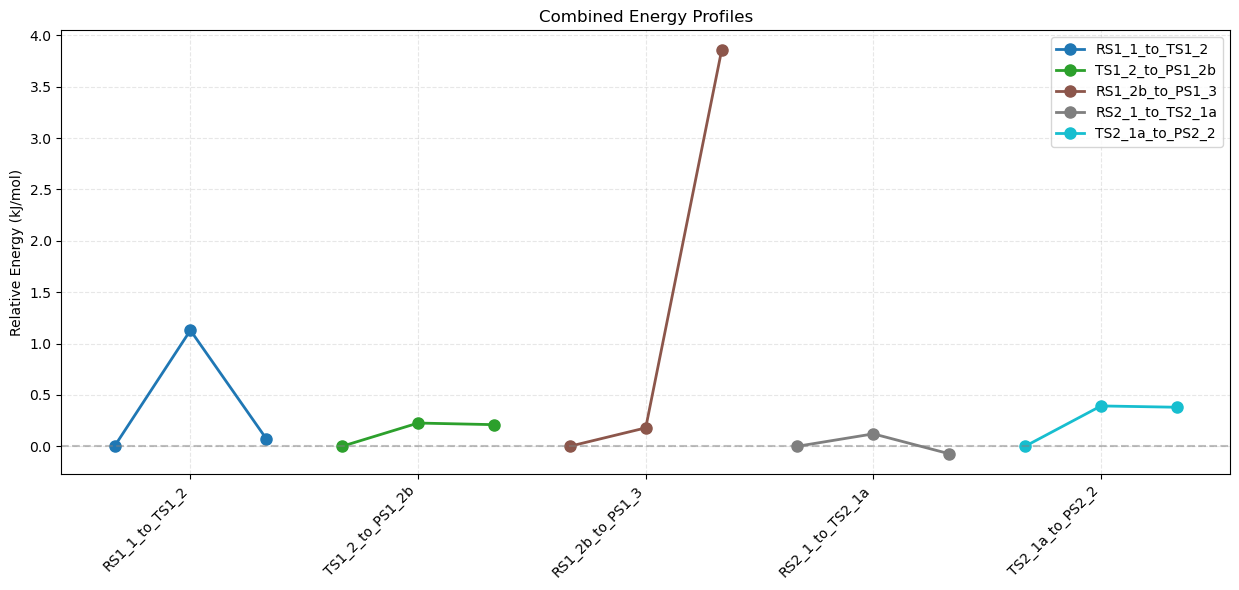


✅ Pipeline complete.


In [7]:
import shutil
import os
import subprocess
import re
import csv
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ------------------------------------------------------------------
# 1. Locate official xTB binary
# ------------------------------------------------------------------
download_dir = Path(r"C:\Users\Nayanika\Downloads\xtb-6.7.1pre-windows-x86_64")
xtb_exe = None
for exe in download_dir.rglob("xtb.exe"):
    xtb_exe = exe
    break
if xtb_exe is None:
    xtb_exe = shutil.which("xtb")
    if xtb_exe:
        print(f"⚠️ Using system xtb: {xtb_exe}")
        xtb_exe = Path(xtb_exe)
    else:
        raise FileNotFoundError("xtb.exe not found.")
XTB_EXE = xtb_exe
print(f"✅ Using xTB: {XTB_EXE}")

# ------------------------------------------------------------------
# 2. Optimization function (same as before, but with final single-point)
# ------------------------------------------------------------------
def run_xtb_jobs(steps: list[str], roles: list[str]) -> None:
    prep_dir = RESULTS_DIR / "pdb_preserving_xtb_qm_inputs"
    for step in steps:
        step_dir = prep_dir / step
        if not step_dir.exists():
            print(f"Skipping {step}: directory {step_dir} does not exist.")
            continue
        cfg = STRUCTURE_SETS[step]
        charge = cfg.charge
        uhf = max(0, cfg.multiplicity - 1)
        for role in roles:
            if role == "TS_constrained":
                xyz_file = step_dir / f"{step}_TS.xyz"
                log_prefix = f"{step}_TS_constrained"
                constraint_file = step_dir / f"{step}_TS_xtb_constraints.inp"
                if not constraint_file.exists():
                    constraint_file = None
            else:
                xyz_file = step_dir / f"{step}_{role}.xyz"
                log_prefix = f"{step}_{role}"
                constraint_file = None
            if not xyz_file.exists():
                print(f"Skipping {step} {role}: XYZ file {xyz_file} not found.")
                continue
            print(f"\n=== Optimizing {step} {role} with xTB ===")
            strategies = [
                (2, "tight",   "normal", 500, 1.0),
                (2, "normal",  "normal", 500, 1.0),
                (2, "loose",   "normal", 500, 1.0),
                (2, "normal",  "diis",   500, 1.0),
                (1, "normal",  "normal", 500, 1.0),
                (1, "loose",   "normal", 500, 1.0),
            ]
            success = False
            last_result = None
            for gfn, opt, scf, etemp, acc in strategies:
                cmd = [
                    str(XTB_EXE), str(xyz_file),
                    "--gfn", str(gfn),
                    "--opt", opt,
                    "--chrg", str(charge),
                    "--uhf", str(uhf),
                    "--scf", scf,
                    "--etemp", str(etemp),
                    "--acc", str(acc),
                ]
                if constraint_file is not None:
                    cmd += ["--input", str(constraint_file)]
                print(f"  Trying GFN{gfn} {opt} opt, SCF={scf}, etemp={etemp} ...")
                env = os.environ.copy()
                env["OMP_NUM_THREADS"] = "1"
                env["OMP_STACKSIZE"] = "1G"
                result = subprocess.run(
                    cmd,
                    cwd=str(step_dir),
                    capture_output=True,
                    text=True,
                    encoding="utf-8",
                    errors="replace",
                    env=env,
                    check=False
                )
                last_result = result
                # Save stdout/stderr to files
                out_file = step_dir / f"{log_prefix}_xtb.out"
                err_file = step_dir / f"{log_prefix}_xtb.err"
                out_file.write_text(result.stdout, encoding="utf-8")
                err_file.write_text(result.stderr, encoding="utf-8")
                if result.returncode == 0:
                    # Copy output files
                    for src, dst in [
                        ("xtbopt.xyz", f"{log_prefix}_xtbopt.xyz"),
                        ("xtbopt.log", f"{log_prefix}_xtbopt.log"),
                        ("xtbrestart", f"{log_prefix}.xtbrestart"),
                    ]:
                        src_path = step_dir / src
                        if src_path.exists():
                            shutil.copy(src_path, step_dir / dst)
                    print(f"✅ {step} {role} optimized with GFN{gfn} {opt} (SCF={scf}).")
                    # Now run a final single-point with etemp=0 to get accurate energy
                    final_xyz = step_dir / f"{log_prefix}_xtbopt.xyz"
                    if not final_xyz.exists():
                        final_xyz = step_dir / "xtbopt.xyz"
                    if final_xyz.exists():
                        print(f"  Running final single-point (etemp=0) for {step} {role}...")
                        cmd_final = [
                            str(XTB_EXE), str(final_xyz),
                            "--gfn", "2",
                            "--chrg", str(charge),
                            "--uhf", str(uhf),
                            "--scf", "normal",
                            "--etemp", "0",
                            "--acc", "1.0",
                        ]
                        if constraint_file is not None:
                            cmd_final += ["--input", str(constraint_file)]
                        result_final = subprocess.run(
                            cmd_final,
                            cwd=str(step_dir),
                            capture_output=True,
                            text=True,
                            encoding="utf-8",
                            errors="replace",
                            env=env,
                            check=False
                        )
                        final_out = step_dir / f"{log_prefix}_final.xtb.out"
                        final_err = step_dir / f"{log_prefix}_final.xtb.err"
                        final_out.write_text(result_final.stdout, encoding="utf-8")
                        final_err.write_text(result_final.stderr, encoding="utf-8")
                        if result_final.returncode == 0:
                            print(f"  ✅ Final single-point energy saved to {final_out}")
                        else:
                            print(f"  ⚠️ Final single-point failed (code {result_final.returncode})")
                    success = True
                    break
                else:
                    print(f"❌ Failed (code {result.returncode}).")
            if not success:
                # Try restart from single-point geometry
                sp_xyz = step_dir / "xtbl.xyz"
                if not sp_xyz.exists():
                    sp_xyz = step_dir / "xtbopt.xyz"
                if sp_xyz.exists():
                    print(f"  Found single-point geometry {sp_xyz.name}. Attempting restart...")
                    restart_xyz = step_dir / f"{log_prefix}_restart.xyz"
                    shutil.copy(sp_xyz, restart_xyz)
                    cmd = [
                        str(XTB_EXE), str(restart_xyz),
                        "--gfn", "2",
                        "--opt", "normal",
                        "--chrg", str(charge),
                        "--uhf", str(uhf),
                        "--scf", "normal",
                        "--etemp", "500",
                    ]
                    if constraint_file is not None:
                        cmd += ["--input", str(constraint_file)]
                    result = subprocess.run(
                        cmd,
                        cwd=str(step_dir),
                        capture_output=True,
                        text=True,
                        encoding="utf-8",
                        errors="replace",
                        env=env,
                        check=False
                    )
                    # Save stdout/stderr
                    out_file = step_dir / f"{log_prefix}_restart_xtb.out"
                    err_file = step_dir / f"{log_prefix}_restart_xtb.err"
                    out_file.write_text(result.stdout, encoding="utf-8")
                    err_file.write_text(result.stderr, encoding="utf-8")
                    if result.returncode == 0:
                        for src, dst in [
                            ("xtbopt.xyz", f"{log_prefix}_xtbopt.xyz"),
                            ("xtbopt.log", f"{log_prefix}_xtbopt.log"),
                            ("xtbrestart", f"{log_prefix}.xtbrestart"),
                        ]:
                            src_path = step_dir / src
                            if src_path.exists():
                                shutil.copy(src_path, step_dir / dst)
                        print(f"✅ {step} {role} optimized via restart.")
                        # Also run final single-point
                        final_xyz = step_dir / f"{log_prefix}_xtbopt.xyz"
                        if final_xyz.exists():
                            cmd_final = [
                                str(XTB_EXE), str(final_xyz),
                                "--gfn", "2",
                                "--chrg", str(charge),
                                "--uhf", str(uhf),
                                "--scf", "normal",
                                "--etemp", "0",
                            ]
                            result_final = subprocess.run(
                                cmd_final,
                                cwd=str(step_dir),
                                capture_output=True,
                                text=True,
                                encoding="utf-8",
                                errors="replace",
                                env=env,
                                check=False
                            )
                            final_out = step_dir / f"{log_prefix}_final.xtb.out"
                            final_err = step_dir / f"{log_prefix}_final.xtb.err"
                            final_out.write_text(result_final.stdout, encoding="utf-8")
                            final_err.write_text(result_final.stderr, encoding="utf-8")
                        success = True
                    else:
                        print(f"❌ Restart failed (code {result.returncode}).")
                        last_result = result
            if not success:
                print(f"❌ All attempts failed for {step} {role}.")
                error_file = step_dir / f"{log_prefix}_opt_failed.log"
                with open(error_file, "w", encoding="utf-8") as f:
                    f.write("STDOUT:\n" + last_result.stdout + "\n\nSTDERR:\n" + last_result.stderr)
                print(f"Error log: {error_file}")

# ------------------------------------------------------------------
# 3. Frequency function (unchanged)
# ------------------------------------------------------------------
def run_xtb_freq(steps: list[str], roles: list[str], temperature: int = 298) -> None:
    for step in steps:
        step_dir = RESULTS_DIR / "pdb_preserving_xtb_qm_inputs" / step
        cfg = STRUCTURE_SETS[step]
        charge = cfg.charge
        uhf = max(0, cfg.multiplicity - 1)
        for role in roles:
            opt_xyz = step_dir / f"{step}_{role}_xtbopt.xyz"
            if not opt_xyz.exists():
                opt_xyz = step_dir / "xtbopt.xyz"
            if not opt_xyz.exists():
                print(f"Skipping freq for {step} {role}: no optimized geometry.")
                continue
            print(f"\n=== Frequency for {step} {role} ===")
            cmd = [
                str(XTB_EXE), str(opt_xyz),
                "--gfn", "2",
                "--hess",
                "--chrg", str(charge),
                "--uhf", str(uhf),
                "--temper", str(temperature),
                "--scf", "normal",
                "--etemp", "500",
            ]
            env = os.environ.copy()
            env["OMP_NUM_THREADS"] = "1"
            result = subprocess.run(
                cmd,
                cwd=str(step_dir),
                capture_output=True,
                text=True,
                encoding="utf-8",
                errors="replace",
                env=env,
                check=False
            )
            # Save stdout/stderr
            out_file = step_dir / f"{step}_{role}_freq.out"
            err_file = step_dir / f"{step}_{role}_freq.err"
            out_file.write_text(result.stdout, encoding="utf-8")
            err_file.write_text(result.stderr, encoding="utf-8")
            if result.returncode == 0:
                print(f"✅ Frequency calculation completed for {step} {role}.")
                # Copy only files that exist
                files_to_copy = [
                    ("vibrations.xyz", f"{step}_{role}_vibrations.xyz"),
                    ("vibspectrum", f"{step}_{role}_vibspectrum"),
                    ("hessian", f"{step}_{role}_hessian"),
                    ("xtbopt.log", f"{step}_{role}_freq.log"),
                ]
                for src, dst in files_to_copy:
                    src_path = step_dir / src
                    if src_path.exists():
                        shutil.copy(src_path, step_dir / dst)
                    else:
                        print(f"   ⚠️ {src} not found – skipping copy.")
                # Check imaginary frequencies from the frequency output
                log = step_dir / f"{step}_{role}_freq.out"
                if log.exists():
                    content = log.read_text(encoding="utf-8", errors="replace")
                    # Look for frequencies in the output
                    imag = re.findall(r"freq\s+\(cm\^\-1\)\s*=\s*([\d.-]+)", content)
                    if imag:
                        neg = [f for f in imag if float(f) < 0]
                        print(f"   Imaginary frequencies: {len(neg)}")
                        if len(neg) == 1 and role == "TS":
                            print("   ✅ TS confirmed (one imaginary frequency).")
                        elif len(neg) > 1 and role == "TS":
                            print("   ⚠️ TS has multiple imaginary frequencies.")
                else:
                    print("   ⚠️ No frequency output found.")
            else:
                print(f"❌ Frequency calculation failed for {step} {role} (code {result.returncode}).")
                print(f"   Error log saved to {err_file}")

# ------------------------------------------------------------------
# 4. Energy extraction – robust version
# ------------------------------------------------------------------
def extract_energies(steps: list[str], roles: list[str]) -> dict:
    all_energies = {}
    for step in steps:
        step_dir = RESULTS_DIR / "pdb_preserving_xtb_qm_inputs" / step
        energies = {}
        for role in roles:
            # Try final single-point first
            out_file = step_dir / f"{step}_{role}_final.xtb.out"
            if not out_file.exists():
                out_file = step_dir / f"{step}_{role}_xtb.out"
                if not out_file.exists():
                    out_file = step_dir / f"{step}_{role}_restart_xtb.out"
            if not out_file.exists():
                # Last resort: try xtbopt.log (but that often contains XYZ)
                out_file = step_dir / f"{step}_{role}_xtbopt.log"
                if not out_file.exists():
                    out_file = step_dir / "xtbopt.log"
            if not out_file.exists():
                print(f"  No output file for {step} {role} – skipping.")
                continue

            content = out_file.read_text(encoding="utf-8", errors="replace")
            # Multiple patterns
            patterns = [
                r"total energy\s*[:=]\s*([-+]?\d*\.\d+)",
                r"E\s*[:=]\s*([-+]?\d*\.\d+)\s+Eh",
                r"Energy\s*[:=]\s*([-+]?\d*\.\d+)",
                r"energy\s*[:=]\s*([-+]?\d*\.\d+)",
                # fallback: any float followed by Eh at end of line
                r"([-+]?\d*\.\d+)\s+Eh\s*$",
                # sometimes energy appears in the Mulliken section
                r"Mulliken charges:.*?total\s+energy\s*[:=]\s*([-+]?\d*\.\d+)",
            ]
            energy_found = None
            for pattern in patterns:
                match = re.search(pattern, content, re.IGNORECASE | re.DOTALL)
                if match:
                    energy_found = float(match.group(1))
                    break
            # If still nothing, scan for any float followed by Eh
            if energy_found is None:
                matches = re.findall(r"([-+]?\d*\.\d+)\s+Eh", content)
                if matches:
                    # Take the last occurrence (usually final energy)
                    energy_found = float(matches[-1])
            if energy_found is not None:
                energies[role] = energy_found
            else:
                print(f"  ⚠️ Could not extract energy from {out_file.name} for {step} {role}.")
        all_energies[step] = energies
    return all_energies

# ------------------------------------------------------------------
# 5. Charge extraction (unchanged)
# ------------------------------------------------------------------
def extract_charges(steps: list[str], roles: list[str]) -> None:
    for step in steps:
        step_dir = RESULTS_DIR / "pdb_preserving_xtb_qm_inputs" / step
        for role in roles:
            out_file = step_dir / f"{step}_{role}_freq.out"
            if not out_file.exists():
                out_file = step_dir / f"{step}_{role}_xtb.out"
            if not out_file.exists():
                continue
            content = out_file.read_text(encoding="utf-8", errors="replace")
            match = re.search(r"Mulliken charges:\s*\n(.*?)(?=\n\s*\n|\Z)", content, re.DOTALL)
            if match:
                lines = match.group(1).strip().splitlines()
                charges = []
                for line in lines:
                    parts = line.split()
                    if len(parts) >= 2:
                        try:
                            charges.append(float(parts[1]))
                        except:
                            pass
                if charges:
                    csv_file = step_dir / f"{step}_{role}_mulliken.csv"
                    with open(csv_file, "w", newline="") as f:
                        writer = csv.writer(f)
                        writer.writerow(["atom_index", "charge"])
                        for i, q in enumerate(charges, start=1):
                            writer.writerow([i, q])
                    print(f"Charges saved for {step} {role} -> {csv_file}")

# ------------------------------------------------------------------
# 6. Plot individual and combined energy profiles
# ------------------------------------------------------------------
def plot_energy_profiles(energies, output_dir=None):
    if output_dir is None:
        output_dir = RESULTS_DIR / "energy_profiles"
    output_dir.mkdir(parents=True, exist_ok=True)

    steps = list(energies.keys())
    profiles = {}
    for step in steps:
        e_dict = energies[step]
        if "RS" in e_dict and "TS" in e_dict and "PS" in e_dict:
            rs = e_dict["RS"]
            ts = e_dict["TS"]
            ps = e_dict["PS"]
            rel = [0.0, (ts-rs)*2625.499638, (ps-rs)*2625.499638]
            profiles[step] = rel
        else:
            profiles[step] = None

    # Individual plots
    for step, rel in profiles.items():
        if rel is None:
            print(f"Skipping {step}: missing data")
            continue
        fig, ax = plt.subplots(figsize=(6, 4))
        x = [0, 1, 2]
        ax.plot(x, rel, marker='o', linestyle='-', linewidth=2, markersize=8, color='royalblue')
        ax.set_xticks(x)
        ax.set_xticklabels(['RS', 'TS', 'PS'])
        ax.set_ylabel('Relative Energy (kJ/mol)')
        ax.set_title(f'Energy Profile: {step}')
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, linestyle='--', alpha=0.3)
        for xi, yi in zip(x, rel):
            ax.text(xi, yi + 0.5, f'{yi:.1f}', ha='center', va='bottom', fontsize=9)
        plt.tight_layout()
        save_path = output_dir / f"{step}_profile.png"
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"✅ Saved individual profile: {save_path}")

    # Combined plot
    n_steps = len(steps)
    fig, ax = plt.subplots(figsize=(max(10, n_steps*2.5), 6))
    colors = plt.cm.tab10(np.linspace(0, 1, n_steps))
    for i, (step, rel) in enumerate(profiles.items()):
        if rel is None:
            continue
        base_x = i * 3
        x = [base_x, base_x+1, base_x+2]
        ax.plot(x, rel, marker='o', linestyle='-', linewidth=2, markersize=8,
                color=colors[i % len(colors)], label=step)
        ax.text(base_x+0.5, -1, 'RS', ha='center', fontsize=8)
        ax.text(base_x+1.5, -1, 'TS', ha='center', fontsize=8)
        ax.text(base_x+2.5, -1, 'PS', ha='center', fontsize=8)
    ax.set_xticks([i*3 + 1 for i in range(n_steps)])
    ax.set_xticklabels(steps, rotation=45, ha='right')
    ax.set_ylabel('Relative Energy (kJ/mol)')
    ax.set_title('Combined Energy Profiles')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    save_path_combined = output_dir / "combined_profile.png"
    fig.savefig(save_path_combined, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✅ Saved combined profile: {save_path_combined}")

    # Display combined inline
    fig, ax = plt.subplots(figsize=(max(10, n_steps*2.5), 6))
    for i, (step, rel) in enumerate(profiles.items()):
        if rel is None:
            continue
        base_x = i * 3
        x = [base_x, base_x+1, base_x+2]
        ax.plot(x, rel, marker='o', linestyle='-', linewidth=2, markersize=8,
                color=colors[i % len(colors)], label=step)
    ax.set_xticks([i*3 + 1 for i in range(n_steps)])
    ax.set_xticklabels(steps, rotation=45, ha='right')
    ax.set_ylabel('Relative Energy (kJ/mol)')
    ax.set_title('Combined Energy Profiles')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# 7. Run the pipeline
# ------------------------------------------------------------------
all_steps = list(STRUCTURE_SETS.keys())
roles = ["RS", "TS", "PS"]

print("="*60)
print("Step 1: Running xTB optimizations + final single-points")
print("="*60)
run_xtb_jobs(all_steps, roles)

print("\n" + "="*60)
print("Step 2: Running frequency calculations")
print("="*60)
run_xtb_freq(all_steps, roles)

print("\n" + "="*60)
print("Step 3: Extracting energies and barriers")
print("="*60)
energies = extract_energies(all_steps, roles)

# Print detailed energies
print("\nEnergies (Hartree):")
for step, e_dict in energies.items():
    print(f"  {step}:")
    for role, e in e_dict.items():
        print(f"    {role}: {e:.8f}")

# Print barrier table
print("\n" + "="*60)
print("QM Barrier Energies (TS - RS)")
print("="*60)
print(f"{'Step':<25} {'Barrier (kJ/mol)':>15}")
print("-"*42)
for step, e_dict in energies.items():
    if "RS" in e_dict and "TS" in e_dict:
        barrier = (e_dict["TS"] - e_dict["RS"]) * 2625.499638
        print(f"{step:<25} {barrier:>15.2f}")
    else:
        print(f"{step:<25} {'N/A':>15}")

print("\n" + "="*60)
print("Step 4: Extracting Mulliken charges")
print("="*60)
extract_charges(all_steps, roles)

print("\n" + "="*60)
print("Step 5: Plotting energy profiles")
print("="*60)
plot_energy_profiles(energies)

print("\n✅ Pipeline complete.")

In [8]:
step_dir = RESULTS_DIR / "pdb_preserving_xtb_qm_inputs" / "RS1_1_to_TS1_2"
log_file = step_dir / "RS1_1_to_TS1_2_RS_xtbopt.log"
if log_file.exists():
    content = log_file.read_text(encoding="utf-8", errors="replace")
    lines = content.splitlines()
    print("=== Last 30 lines of log ===")
    for line in lines[-30:]:
        print(line)
else:
    print("Log file not found.")

=== Last 30 lines of log ===
H            7.92327501981781        0.20303019391014       -0.92443361776142
H            1.19416728675571        0.37172910472627       -3.41730414251147
H            3.74601669695040        2.07381663511890       -3.85974789237842
H            0.96548646245074        2.62348545221737       -2.70791537351312
H            2.45199500278143        4.43217668144164       -1.72623209655063
H            3.44302257013905        4.38403806505641       -3.18912980490438
H            1.44787896932384        5.08428592431296       -4.52710097630500
H            0.47186616174087        5.11526738085135       -3.05680011444768
H            1.26110908705473        7.39773723998882       -3.65681719967738
H            1.94639980195894        6.89212570926576       -2.11169748770324
H            2.93595367456826        6.85163743807953       -3.57032220174699
H            0.17722048876686       -2.87208089460581       -2.65909082129258
H           -1.29999757909135      

In [9]:
# ------------------------------------------------------------------
# Barrier summary table
# ------------------------------------------------------------------
print("\n" + "="*60)
print("QM Barrier Energies (TS - RS)")
print("="*60)
print(f"{'Step':<25} {'Barrier (kJ/mol)':>15}")
print("-"*42)

for step, e_dict in energies.items():
    if "RS" in e_dict and "TS" in e_dict:
        barrier = (e_dict["TS"] - e_dict["RS"]) * 2625.499638
        print(f"{step:<25} {barrier:>15.2f}")
    else:
        print(f"{step:<25} {'N/A':>15}")


QM Barrier Energies (TS - RS)
Step                      Barrier (kJ/mol)
------------------------------------------
RS1_1_to_TS1_2                       1.13
TS1_2_to_PS1_2b                      0.23
RS1_2b_to_PS1_3                      0.18
RS2_1_to_TS2_1a                      0.12
TS2_1a_to_PS2_2                      0.39


## Run one xTB test only after `xtb found:` is not `None`

## Optional constrained TS xTB test

## Run all xTB jobs only after the one-step test works

In [10]:
# Uncomment only when ready.
run_xtb_jobs(list(STRUCTURE_SETS), roles=["RS", "TS", "PS"])


=== Optimizing RS1_1_to_TS1_2 RS with xTB ===
  Trying GFN2 tight opt, SCF=normal, etemp=500 ...
✅ RS1_1_to_TS1_2 RS optimized with GFN2 tight (SCF=normal).
  Running final single-point (etemp=0) for RS1_1_to_TS1_2 RS...
  ✅ Final single-point energy saved to D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_evb_qm\pdb_preserving_xtb_qm_inputs\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS_final.xtb.out

=== Optimizing RS1_1_to_TS1_2 TS with xTB ===
  Trying GFN2 tight opt, SCF=normal, etemp=500 ...
✅ RS1_1_to_TS1_2 TS optimized with GFN2 tight (SCF=normal).
  Running final single-point (etemp=0) for RS1_1_to_TS1_2 TS...
  ✅ Final single-point energy saved to D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_evb_qm\pdb_preserving_xtb_qm_inputs\RS1_1_to_TS1_2\RS1_1_to_TS1_2_TS_final.xtb.out

=== Optimizing RS1_1_to_TS1_2 PS with xTB ===
  Trying GFN2 tight opt, SCF=normal, etemp=500 ...
✅ RS1_1_to_TS1_2 PS optimized with GFN2 tight (SCF=normal).
  Running final single-point (etemp=0) for RS1_1_to_TS1_2 PS...
  ✅ Fina

## Optional fast VeloxChem SMILES guesses

No relaxed QM scan. No 3D viewer.

In [11]:
# Uncomment only if VeloxChem is importable in this environment.
# run_veloxchem_fast(["RS2_1_to_TS2_1a"])


# FINAL: Run all QM hybrid/double-hybrid methods

This section is self-contained and uses the PDB/XYZ files already prepared by this notebook.

It runs the following methods for **RS, TS and PS** for every reaction step:

1. B3LYP-D3BJ/def2-SVP
2. PBE0-D3BJ/def2-SVP
3. PBE0-D3BJ/def2-TZVP
4. ωB97M-V/def2-TZVP
5. ωB97X-V/def2-TZVP
6. PBE0-DH/def2-TZVP

By default:
- RS/PS = optimization + frequencies
- TS = transition-state optimization + frequencies

Each method gets its own directory, and the notebook saves the ORCA input, output, optimized geometry, energy, Mulliken charges, frequencies and a summary table.

**This is computationally expensive. Test one state first before launching the full set.**


In [12]:

# ============================================================
# QM METHOD CONFIGURATION
# ============================================================

from pathlib import Path
import os
import re
import csv
import shutil
import subprocess
import time

# Main output directory for ALL hybrid calculations.
HYBRID_RESULTS_DIR = RESULTS_DIR / "all_hybrid_qm"

# Set this if ORCA is not on PATH.
# Example:
# ORCA_EXE = Path(r"C:\orca_6_1_0\orca.exe")
ORCA_EXE = None

# Resources
ORCA_NPROCS = 8
ORCA_MAXCORE_MB = 3000

# True = actually launch ORCA.
# False = only generate all inputs.
RUN_ORCA = False

# For the first test, keep this small.
TEST_ONLY = True

# If TEST_ONLY=True, only this job is launched.
TEST_METHOD = "PBE0_def2SVP"
TEST_STEP = list(STRUCTURE_SETS)[0]
TEST_STATE = "RS"

METHODS = {
    "B3LYP_def2SVP": {
        "orca": "B3LYP D3BJ def2-SVP",
        "description": "B3LYP-D3BJ/def2-SVP",
    },
    "PBE0_def2SVP": {
        "orca": "PBE0 D3BJ def2-SVP",
        "description": "PBE0-D3BJ/def2-SVP",
    },
    "PBE0_def2TZVP": {
        "orca": "PBE0 D3BJ def2-TZVP",
        "description": "PBE0-D3BJ/def2-TZVP",
    },
    "wB97M-V_def2TZVP": {
        "orca": "wB97M-V def2-TZVP",
        "description": "ωB97M-V/def2-TZVP",
    },
    "wB97X-V_def2TZVP": {
        "orca": "wB97X-V def2-TZVP",
        "description": "ωB97X-V/def2-TZVP",
    },
    "PBE0-DH_def2TZVP": {
        "orca": "PBE0-DH def2-TZVP",
        "description": "PBE0-DH/def2-TZVP",
    },
}

HYBRID_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Hybrid QM output:", HYBRID_RESULTS_DIR)
print("Methods:", ", ".join(METHODS))
print("RUN_ORCA:", RUN_ORCA)
print("TEST_ONLY:", TEST_ONLY)


Hybrid QM output: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_evb_qm\all_hybrid_qm
Methods: B3LYP_def2SVP, PBE0_def2SVP, PBE0_def2TZVP, wB97M-V_def2TZVP, wB97X-V_def2TZVP, PBE0-DH_def2TZVP
RUN_ORCA: False
TEST_ONLY: True


In [13]:

# ============================================================
# ROBUST ORCA LOCATOR
# ============================================================

def locate_orca():
    if ORCA_EXE is not None:
        p = Path(ORCA_EXE)
        if p.exists():
            return p
        raise FileNotFoundError(
            f"ORCA_EXE was set but does not exist:\n{p}"
        )

    found = shutil.which("orca")
    if found:
        return Path(found)

    found = shutil.which("orca.exe")
    if found:
        return Path(found)

    return None


ORCA_PATH = locate_orca()

if ORCA_PATH:
    print("ORCA found:", ORCA_PATH)
else:
    print(
        "ORCA was NOT found. Input generation will still work.\n"
        "Set ORCA_EXE to the full path to orca.exe before RUN_ORCA=True."
    )


ORCA was NOT found. Input generation will still work.
Set ORCA_EXE to the full path to orca.exe before RUN_ORCA=True.


In [14]:

# ============================================================
# HELPERS: PDB/XYZ -> ORCA INPUT
# ============================================================

def get_xyz_for_step_state(step, state):
    """
    Uses the PDB-preserving XYZ files made by the original notebook.
    """
    candidates = [
        RESULTS_DIR / "pdb_preserving_xtb_qm_inputs" / step / f"{step}_{state}.xyz",
        RESULTS_DIR / "pdb_preserving_xtb_qm_inputs" / step / f"{step}_{state}_xtbopt.xyz",
    ]

    for p in candidates:
        if p.exists():
            return p

    raise FileNotFoundError(
        f"No XYZ found for {step}/{state}.\n"
        f"Expected one of:\n" +
        "\n".join(str(x) for x in candidates)
    )


def read_xyz_coordinates(xyz_path):
    lines = xyz_path.read_text(
        encoding="utf-8",
        errors="replace"
    ).splitlines()

    n = int(lines[0].strip())
    coords = []

    for line in lines[2:2+n]:
        parts = line.split()
        if len(parts) >= 4:
            coords.append(
                (parts[0], float(parts[1]), float(parts[2]), float(parts[3]))
            )

    if len(coords) != n:
        raise ValueError(
            f"XYZ atom count mismatch in {xyz_path}: "
            f"{n} expected, {len(coords)} read."
        )

    return coords


def write_hybrid_input(
    input_path,
    xyz_path,
    method_name,
    state,
    charge,
    multiplicity,
):
    coords = read_xyz_coordinates(xyz_path)
    method = METHODS[method_name]["orca"]

    if state == "TS":
        job_keywords = "OptTS NumFreq TightSCF"
    else:
        job_keywords = "Opt NumFreq TightSCF"

    lines = [
        f"! {method} {job_keywords}",
        "",
        "%pal",
        f"   nprocs {ORCA_NPROCS}",
        "end",
        "",
        f"%maxcore {ORCA_MAXCORE_MB}",
        "",
        "%output",
        "   Print[P_Mulliken] 1",
        "end",
        "",
        f"* xyz {charge} {multiplicity}",
    ]

    for element, x, y, z in coords:
        lines.append(
            f"  {element:<2s} {x:14.8f} {y:14.8f} {z:14.8f}"
        )

    lines.extend(["*", ""])

    input_path.parent.mkdir(parents=True, exist_ok=True)
    input_path.write_text(
        "\n".join(lines),
        encoding="utf-8"
    )


In [15]:

# ============================================================
# PREPARE ALL METHODS × ALL STEPS × RS/TS/PS
# ============================================================

def hybrid_job_dir(method_name, step, state):
    p = (
        HYBRID_RESULTS_DIR /
        method_name /
        step /
        state
    )

    for sub in (
        "input",
        "output",
        "geometry",
        "energy",
        "charges",
        "frequencies",
    ):
        (p / sub).mkdir(parents=True, exist_ok=True)

    return p


def prepare_all_hybrid_inputs():
    rows = []

    for method_name in METHODS:

        for step, cfg in STRUCTURE_SETS.items():

            for state, pdb_name in [
                ("RS", cfg.rs_pdb),
                ("TS", cfg.ts_pdb),
                ("PS", cfg.ps_pdb),
            ]:

                jobdir = hybrid_job_dir(
                    method_name,
                    step,
                    state
                )

                xyz = get_xyz_for_step_state(
                    step,
                    state
                )

                # Keep a copy of the exact geometry used.
                geometry_copy = (
                    jobdir /
                    "geometry" /
                    f"{step}_{state}_starting.xyz"
                )

                if not geometry_copy.exists():
                    shutil.copy2(xyz, geometry_copy)

                inp = (
                    jobdir /
                    "input" /
                    f"{step}_{state}_{method_name}.inp"
                )

                write_hybrid_input(
                    inp,
                    xyz,
                    method_name,
                    state,
                    cfg.charge,
                    cfg.multiplicity,
                )

                rows.append({
                    "method": method_name,
                    "method_description": METHODS[method_name]["description"],
                    "step": step,
                    "state": state,
                    "source_xyz": str(xyz),
                    "input": str(inp),
                    "output": str(jobdir / "output" / f"{inp.stem}.out"),
                    "charge": cfg.charge,
                    "multiplicity": cfg.multiplicity,
                    "status": "prepared",
                })

    manifest = HYBRID_RESULTS_DIR / "all_hybrid_jobs.csv"

    with manifest.open(
        "w",
        newline="",
        encoding="utf-8"
    ) as f:
        writer = csv.DictWriter(
            f,
            fieldnames=list(rows[0].keys())
        )
        writer.writeheader()
        writer.writerows(rows)

    print("=" * 72)
    print("ALL HYBRID INPUTS PREPARED")
    print("=" * 72)
    print("Jobs:", len(rows))
    print("Manifest:", manifest)

    return rows


hybrid_jobs = prepare_all_hybrid_inputs()


ALL HYBRID INPUTS PREPARED
Jobs: 90
Manifest: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_evb_qm\all_hybrid_qm\all_hybrid_jobs.csv


In [16]:

# ============================================================
# VERIFY ALL INPUT FILES EXIST
# ============================================================

missing_inputs = []

for row in hybrid_jobs:
    p = Path(row["input"])
    if not p.exists():
        missing_inputs.append(p)

print("Expected inputs:", len(hybrid_jobs))
print("Missing inputs :", len(missing_inputs))

if missing_inputs:
    for p in missing_inputs[:20]:
        print("MISSING:", p)
    raise RuntimeError("Some hybrid input files were not created.")

print("SUCCESS: every hybrid job has an ORCA input file.")


Expected inputs: 90
Missing inputs : 0
SUCCESS: every hybrid job has an ORCA input file.


In [17]:

# ============================================================
# RUN ONE JOB FIRST
# ============================================================

def run_orca_job(method_name, step, state):
    if ORCA_PATH is None:
        raise RuntimeError(
            "ORCA executable not found. Set ORCA_EXE first."
        )

    cfg = STRUCTURE_SETS[step]

    jobdir = hybrid_job_dir(
        method_name,
        step,
        state
    )

    inp = (
        jobdir /
        "input" /
        f"{step}_{state}_{method_name}.inp"
    )

    out = (
        jobdir /
        "output" /
        f"{step}_{state}_{method_name}.out"
    )

    if not inp.exists():
        raise FileNotFoundError(inp)

    env = os.environ.copy()

    # ORCA on Windows works most reliably with its own directory
    # available on PATH.
    env["PATH"] = (
        str(ORCA_PATH.parent)
        + os.pathsep
        + env.get("PATH", "")
    )

    print("=" * 72)
    print("RUNNING ORCA")
    print("Method:", METHODS[method_name]["description"])
    print("Step  :", step)
    print("State :", state)
    print("Input :", inp)
    print("Output:", out)
    print("=" * 72)

    start = time.time()

    with out.open("w", encoding="utf-8", errors="replace") as fout:
        result = subprocess.run(
            [str(ORCA_PATH), str(inp)],
            cwd=str(jobdir / "output"),
            stdout=fout,
            stderr=subprocess.STDOUT,
            env=env,
            check=False,
        )

    elapsed = time.time() - start

    print("Return code:", result.returncode)
    print(f"Runtime: {elapsed/60:.2f} min")

    if result.returncode != 0:
        raise RuntimeError(
            f"ORCA failed.\n"
            f"Read:\n{out}"
        )

    return out


# Safe first test:
if RUN_ORCA:
    test_out = run_orca_job(
        TEST_METHOD,
        TEST_STEP,
        TEST_STATE,
    )
    print("Test completed:", test_out)
else:
    print("RUN_ORCA=False -> no QM calculation launched.")


RUN_ORCA=False -> no QM calculation launched.


In [18]:

# ============================================================
# RUN ALL METHODS × ALL STEPS × RS/TS/PS
# ============================================================
#
# IMPORTANT:
# Set:
#     RUN_ORCA = True
#     TEST_ONLY = False
#
# before executing this cell.
#
# This launches:
#   6 methods × 5 steps × 3 states = 90 QM calculations.
#
# Each job is run separately so one failure is logged without
# destroying the entire campaign.
# ============================================================

def run_all_hybrid_jobs():
    if ORCA_PATH is None:
        raise RuntimeError(
            "ORCA executable not found. Set ORCA_EXE."
        )

    if not RUN_ORCA:
        print(
            "RUN_ORCA=False. Inputs are prepared but calculations "
            "were intentionally not launched."
        )
        return

    failures = []
    completed = 0

    for method_name in METHODS:

        for step, cfg in STRUCTURE_SETS.items():

            for state in ("RS", "TS", "PS"):

                if TEST_ONLY and not (
                    method_name == TEST_METHOD
                    and step == TEST_STEP
                    and state == TEST_STATE
                ):
                    continue

                try:
                    run_orca_job(
                        method_name,
                        step,
                        state,
                    )
                    completed += 1

                except Exception as exc:

                    failures.append({
                        "method": method_name,
                        "step": step,
                        "state": state,
                        "error": str(exc),
                    })

                    print(
                        f"FAILED: {method_name} "
                        f"{step} {state}"
                    )

    failure_csv = HYBRID_RESULTS_DIR / "failed_jobs.csv"

    if failures:
        with failure_csv.open(
            "w",
            newline="",
            encoding="utf-8"
        ) as f:
            writer = csv.DictWriter(
                f,
                fieldnames=["method", "step", "state", "error"]
            )
            writer.writeheader()
            writer.writerows(failures)

    print("=" * 72)
    print("QM CAMPAIGN FINISHED")
    print("Completed:", completed)
    print("Failed   :", len(failures))
    if failures:
        print("Failures :", failure_csv)
    print("=" * 72)


run_all_hybrid_jobs()


RuntimeError: ORCA executable not found. Set ORCA_EXE.


## Extract energies and Mulliken charges

After ORCA finishes, the next cell parses the output files and saves:

```text
all_hybrid_qm/
  summaries/
    qm_energy_summary.csv
    qm_barrier_summary.csv
    qm_mulliken_charges.csv
```

The QM `TS - RS` quantity is an electronic-energy difference. It is **not** directly the EVB ΔG‡.


In [ ]:

# ============================================================
# PARSE ORCA ENERGIES + MULLIKEN CHARGES
# ============================================================

def parse_final_energy(out_file):
    text = out_file.read_text(
        encoding="utf-8",
        errors="replace"
    )

    matches = re.findall(
        r"FINAL SINGLE POINT ENERGY\s+(-?\d+\.\d+)",
        text
    )

    if not matches:
        return None

    return float(matches[-1])


def parse_mulliken_charges(out_file):
    text = out_file.read_text(
        encoding="utf-8",
        errors="replace"
    )

    lines = text.splitlines()
    rows = []

    start = None

    for i, line in enumerate(lines):
        if "MULLIKEN ATOMIC CHARGES" in line.upper():
            start = i + 1
            break

    if start is None:
        return rows

    for line in lines[start:]:
        if not line.strip():
            if rows:
                break
            continue

        if "Sum of atomic charges" in line:
            break

        m = re.match(
            r"\s*(\d+)\s+([A-Za-z]+)\s+(-?\d+\.\d+)",
            line
        )

        if m:
            rows.append({
                "atom_index": int(m.group(1)),
                "element": m.group(2),
                "mulliken_charge": float(m.group(3)),
            })

    return rows


def collect_qm_results():
    summary = []
    charge_rows = []

    for method_name in METHODS:

        for step in STRUCTURE_SETS:

            for state in ("RS", "TS", "PS"):

                jobdir = hybrid_job_dir(
                    method_name,
                    step,
                    state
                )

                out = (
                    jobdir /
                    "output" /
                    f"{step}_{state}_{method_name}.out"
                )

                if not out.exists():
                    continue

                energy = parse_final_energy(out)
                charges = parse_mulliken_charges(out)

                summary.append({
                    "method": method_name,
                    "step": step,
                    "state": state,
                    "energy_hartree": energy,
                    "output": str(out),
                })

                for row in charges:
                    charge_rows.append({
                        "method": method_name,
                        "step": step,
                        "state": state,
                        **row,
                    })

    summaries_dir = HYBRID_RESULTS_DIR / "summaries"
    summaries_dir.mkdir(parents=True, exist_ok=True)

    energy_csv = summaries_dir / "qm_energy_summary.csv"

    if summary:
        with energy_csv.open(
            "w",
            newline="",
            encoding="utf-8"
        ) as f:
            writer = csv.DictWriter(
                f,
                fieldnames=list(summary[0].keys())
            )
            writer.writeheader()
            writer.writerows(summary)

    charge_csv = summaries_dir / "qm_mulliken_charges.csv"

    if charge_rows:
        with charge_csv.open(
            "w",
            newline="",
            encoding="utf-8"
        ) as f:
            writer = csv.DictWriter(
                f,
                fieldnames=list(charge_rows[0].keys())
            )
            writer.writeheader()
            writer.writerows(charge_rows)

    # Calculate TS-RS electronic barriers.
    barrier_rows = []

    for method_name in METHODS:

        for step in STRUCTURE_SETS:

            e = {
                row["state"]: row["energy_hartree"]
                for row in summary
                if row["method"] == method_name
                and row["step"] == step
            }

            if e.get("RS") is None or e.get("TS") is None:
                continue

            delta_h = (
                e["TS"] - e["RS"]
            )

            barrier_rows.append({
                "method": method_name,
                "step": step,
                "RS_hartree": e["RS"],
                "TS_hartree": e["TS"],
                "PS_hartree": e.get("PS"),
                "QM_TS_minus_RS_hartree": delta_h,
                "QM_TS_minus_RS_kJmol": delta_h * HARTREE_TO_KJMOL,
                "QM_TS_minus_RS_kcalmol": (
                    delta_h * HARTREE_TO_KJMOL / 4.184
                ),
            })

    barrier_csv = summaries_dir / "qm_barrier_summary.csv"

    if barrier_rows:
        with barrier_csv.open(
            "w",
            newline="",
            encoding="utf-8"
        ) as f:
            writer = csv.DictWriter(
                f,
                fieldnames=list(barrier_rows[0].keys())
            )
            writer.writeheader()
            writer.writerows(barrier_rows)

    print("Energy summary:", energy_csv)
    print("Charge summary:", charge_csv)
    print("Barrier summary:", barrier_csv)

    return summary, barrier_rows, charge_rows


if RUN_ORCA:
    qm_summary, qm_barriers, qm_charges = collect_qm_results()
else:
    print(
        "No ORCA parsing performed because RUN_ORCA=False."
    )
